# Project Optimal Infill Density
- This is to assess the PLA Experimental Dataset and know the nature of the data.
- Various Analysis Testing will be used in order to explore relationship between data features.
- Graphs and other statistical methods are considered based on the expected results and supporting articles on what methods will be needed in order to arrive to a statistically sound result.

## Phase I - Data Understanding and Validation

### 1.1 Importing Libraries  

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import math

# To avoid displaying FutureWarnings from pandas/numpy
warnings.filterwarnings('ignore', category=FutureWarning)

# Allow to show all columns when printing dataframes
pd.set_option('display.max_columns', None)

# Set seaborn theme for better aesthetics
sns.set_theme(style="whitegrid")

### 1.2 Loading Dataset

In [3]:
# Load the dataset
df = pd.read_csv("PAASE Experiment (PLA) Converted.csv", header=0)
df.head()

,item_no,print_date,start_time,end_time,specimen_id,replicate_no,infill_density_percent,infill_pattern,material_type,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,remarks
0,1,4/14/2026,15:04:53,15:14:15,PLA_10_R1,1,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,0.0536,0.1561,1.41,1.44,0.014,36.1809,1.48981,Nagbedlevel kaya matagal (randomly)
1,2,4/14/2026,15:15:57,15:23:30,PLA_10_R2,2,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,0.0536,0.1258,1.40,1.44,0.013,35.8098,1.68293,NaN
2,3,4/14/2026,15:25:15,15:33:12,PLA_10_R3,3,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,0.0536,0.1325,1.40,1.44,0.013,33.5701,1.92406,NaN
3,4,4/14/2026,15:34:26,15:42:32,PLA_10_R4,4,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,0.0536,0.1350,1.40,1.44,0.013,36.1737,1.59461,NaN
4,5,4/14/2026,15:43:59,15:51:56,PLA_10_R5,5,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,0.0536,0.1325,1.41,1.44,0.013,36.8314,1.54971,NaN


### 1.3 Inspection of Dataset Structure

In [4]:
# Display dataset shape
print("Dataset shape: ", df.shape)

Dataset shape:  (50, 23)


In [5]:
# Print summary info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   item_no                 50 non-null     int64  
 1   print_date              50 non-null     str    
 2   start_time              50 non-null     str    
 3   end_time                50 non-null     str    
 4   specimen_id             50 non-null     str    
 5   replicate_no            50 non-null     int64  
 6   infill_density_percent  50 non-null     int64  
 7   infill_pattern          50 non-null     str    
 8   material_type           50 non-null     str    
 9   layer_height_mm         50 non-null     float64
 10  nozzle_temp_c           50 non-null     int64  
 11  bed_temp_c              50 non-null     int64  
 12  wall_count              50 non-null     int64  
 13  top_layers              50 non-null     int64  
 14  bottom_layers           50 non-null     int64  
 15  pr

In [6]:
# Display data types of each column
print("Data types:\n", df.dtypes)

Data types:
 item_no                     int64
print_date                    str
start_time                    str
end_time                      str
specimen_id                   str
replicate_no                int64
infill_density_percent      int64
infill_pattern                str
material_type                 str
layer_height_mm           float64
nozzle_temp_c               int64
bed_temp_c                  int64
wall_count                  int64
top_layers                  int64
bottom_layers               int64
print_time_slicer         float64
print_time_actual         float64
actual_specimen_mass_g    float64
slicer_specimen_mass_g    float64
energy_used_kwh           float64
ultimate_stress_mpa       float64
strain_percent            float64
remarks                       str
dtype: object


### 1.4 Identification adn Grouping of Variable Categories

In [7]:
# Classify columns in to data nature (Independent Variable, Dependent Variable, Control Variable)
indep_vars = ['infill_density_percent']

dep_vars = ['print_time_slicer',
            'print_time_actual',
            'actual_specimen_mass_g',
            'slicer_specimen_mass_g',
            'energy_used_kwh',
            'ultimate_stress_mpa',
            'strain_percent']

con_vars = ['material_type',
            'infill_pattern',
            'layer_height_mm',
            'nozzle_temp_c',
            'bed_temp_c',
            'wall_count',
            'top_layers',
            'bottom_layers']

In [8]:
# Summary statistics for variables
df[indep_vars].info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 1 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   infill_density_percent  50 non-null     int64
dtypes: int64(1)
memory usage: 532.0 bytes


In [9]:
df[dep_vars].info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   print_time_slicer       50 non-null     float64
 1   print_time_actual       50 non-null     float64
 2   actual_specimen_mass_g  50 non-null     float64
 3   slicer_specimen_mass_g  50 non-null     float64
 4   energy_used_kwh         50 non-null     float64
 5   ultimate_stress_mpa     50 non-null     float64
 6   strain_percent          50 non-null     float64
dtypes: float64(7)
memory usage: 2.9 KB


In [10]:
df[con_vars].info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   material_type    50 non-null     str    
 1   infill_pattern   50 non-null     str    
 2   layer_height_mm  50 non-null     float64
 3   nozzle_temp_c    50 non-null     int64  
 4   bed_temp_c       50 non-null     int64  
 5   wall_count       50 non-null     int64  
 6   top_layers       50 non-null     int64  
 7   bottom_layers    50 non-null     int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 4.0 KB


In [11]:
# Summary statistics for variables
df[indep_vars].describe()

,infill_density_percent
count,50.000000
mean,55.000000
std,29.014423
min,10.000000
25%,30.000000
50%,55.000000
75%,80.000000
max,100.000000


In [12]:
df[dep_vars].describe()

,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.057430,0.138206,1.584200,1.604000,0.016480,40.106212,2.189428
std,0.003908,0.007960,0.103944,0.101539,0.002873,2.909612,0.396485
min,0.053300,0.119400,1.400000,1.440000,0.011000,33.570100,1.489810
25%,0.054200,0.133600,1.510000,1.520000,0.015000,39.003125,1.867142
50%,0.056100,0.136250,1.590000,1.605000,0.017000,40.002550,2.227275
75%,0.060800,0.141025,1.670000,1.700000,0.018000,40.956675,2.538385
max,0.064200,0.166400,1.750000,1.760000,0.023000,52.598100,2.909330


In [13]:
df[con_vars].describe()

,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers
count,5.000000e+01,50.0,50.0,50.0,50.0,50.0
mean,2.000000e-01,220.0,50.0,2.0,5.0,5.0
std,5.607473e-17,0.0,0.0,0.0,0.0,0.0
min,2.000000e-01,220.0,50.0,2.0,5.0,5.0
25%,2.000000e-01,220.0,50.0,2.0,5.0,5.0
50%,2.000000e-01,220.0,50.0,2.0,5.0,5.0
75%,2.000000e-01,220.0,50.0,2.0,5.0,5.0
max,2.000000e-01,220.0,50.0,2.0,5.0,5.0


## Phase II - Data Cleaning and Preprocessing

### 2.1 Missing Value Inspection

In [14]:
# Check for missing values in the dataset
print('Missing values in independent variables:')
print(df[indep_vars].isnull().sum())
print('\nMissing values in dependent variables:')
print(df[dep_vars].isnull().sum())
print('\nMissing values in control variables:')
print(df[con_vars].isnull().sum())

Missing values in independent variables:
infill_density_percent    0
dtype: int64

Missing values in dependent variables:
print_time_slicer         0
print_time_actual         0
actual_specimen_mass_g    0
slicer_specimen_mass_g    0
energy_used_kwh           0
ultimate_stress_mpa       0
strain_percent            0
dtype: int64

Missing values in control variables:
material_type      0
infill_pattern     0
layer_height_mm    0
nozzle_temp_c      0
bed_temp_c         0
wall_count         0
top_layers         0
bottom_layers      0
dtype: int64


### 2.2 Checking for Duplicates

In [15]:
# Check for duplicate in the dataset
duplicate_ids = df[df.duplicated(subset=['specimen_id'], keep=False)]
print(f"Number of duplicated specimen IDs: {len(duplicate_ids)}")

# Check for identical measurements across key outcome columns
identical_results = df[df.duplicated(subset=dep_vars, keep=False)]
print(f"Number of identical rows: {len(identical_results)}")

Number of duplicated specimen IDs: 0
Number of identical rows: 0


### 2.3 Outlier Detection

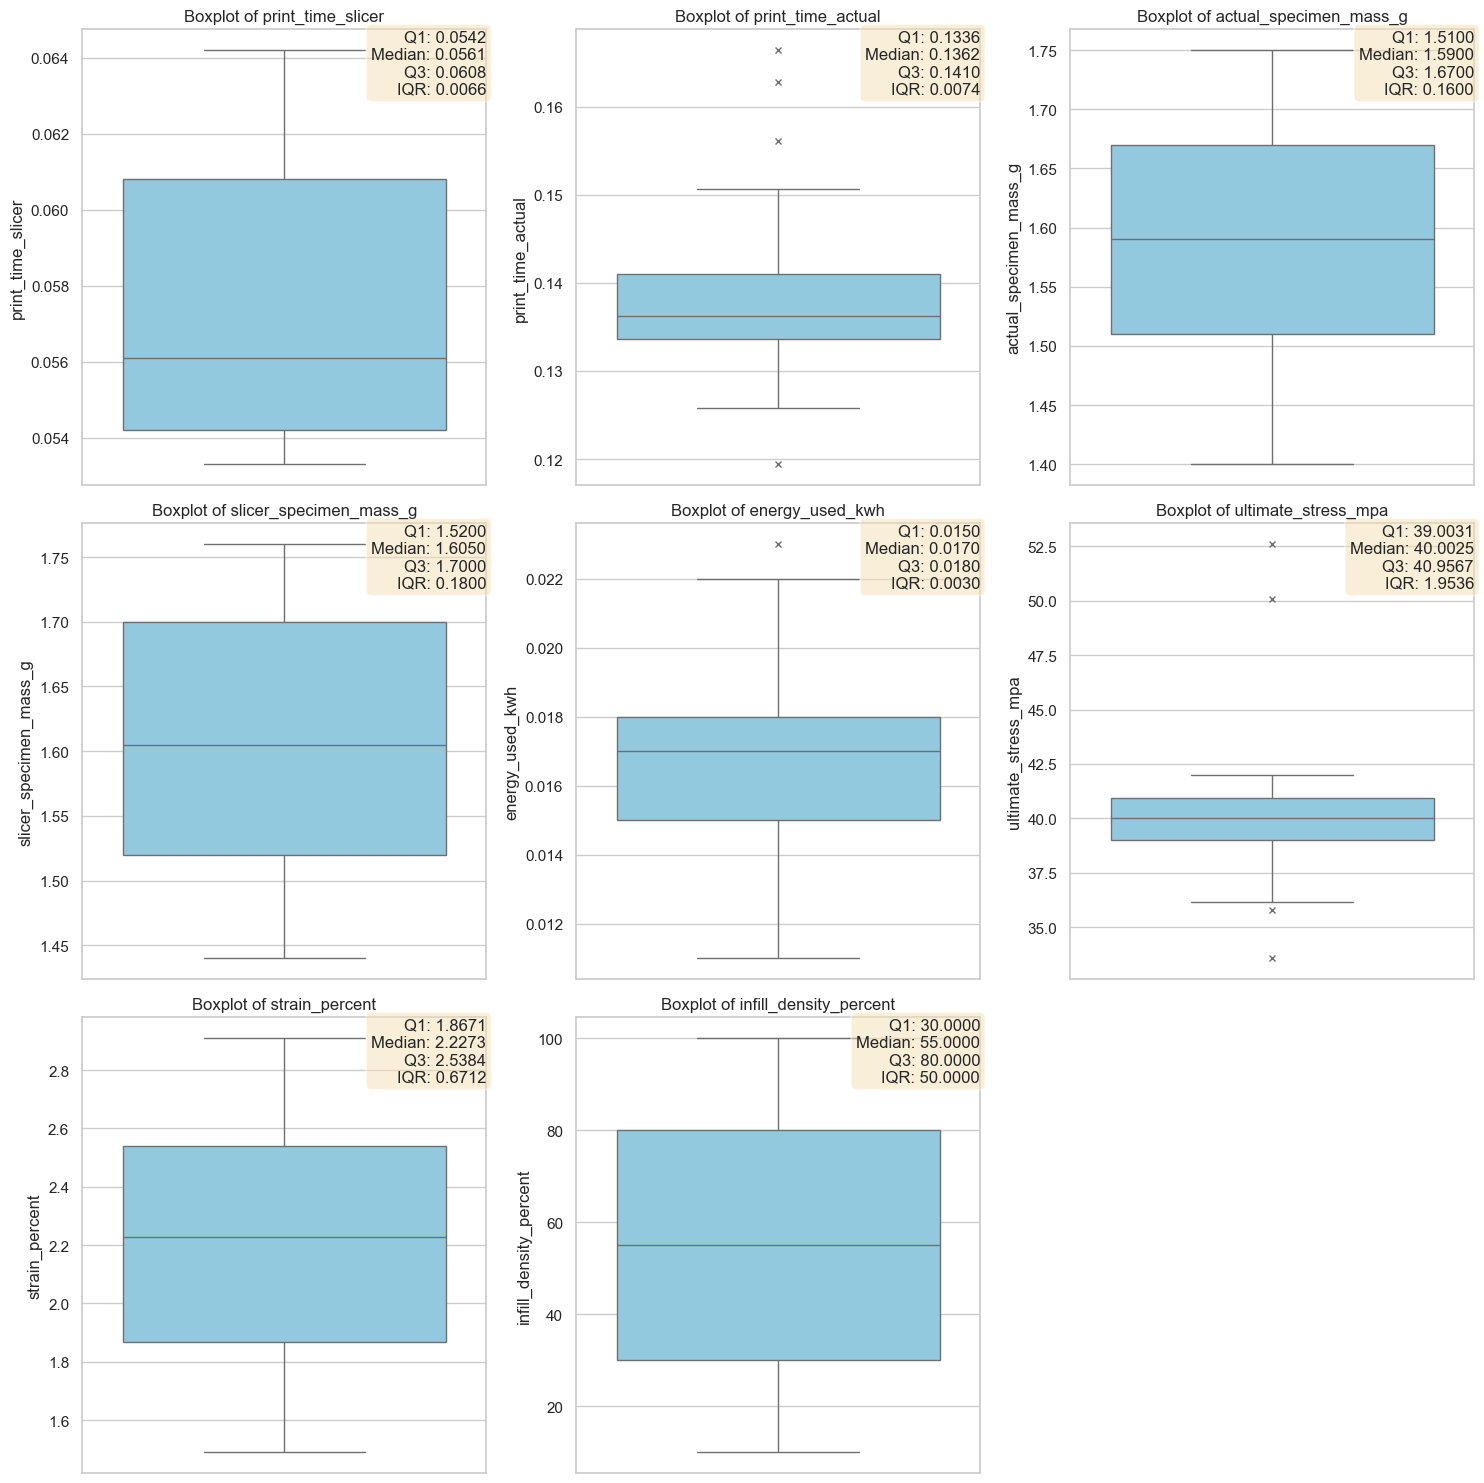

In [35]:
# Boxplot of Dependent Variables
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()
all_vars = dep_vars + indep_vars

for i, var in enumerate(all_vars):
    ax = axes[i]
    
    plt.subplot(3, 3, i + 1)
    sns.boxplot(
        y=df[var],
        color='skyblue',
        ax=ax,
        flierprops=dict(markerfacecolor='red', marker='x', markersize=5, linestyle='none')
        )
    plt.title(f'Boxplot of {var}')

        # Compute statistics
    q1 = df[var].quantile(0.25)
    q2 = df[var].quantile(0.50)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    
    stats_text = (
        f'Q1: {q1:.4f}\n'
        f'Median: {q2:.4f}\n'
        f'Q3: {q3:.4f}\n'
        f'IQR: {iqr:.4f}'
    )
    
    # Stable placement (top-right corner)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    ax.text(
        xlim[1], ylim[1],
        stats_text,
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        verticalalignment='top',
        horizontalalignment='right'
    )

# Hide unused subplots
for idx in range(len(all_vars), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Phase III - Exploratory Data Analysis (EDA)

### 3.1 Descriptive Statistics

In [17]:
df[indep_vars + dep_vars + con_vars].describe()

,infill_density_percent,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,ultimate_stress_mpa,strain_percent,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.0,50.0,50.0,50.0,50.0
mean,55.000000,0.057430,0.138206,1.584200,1.604000,0.016480,40.106212,2.189428,2.000000e-01,220.0,50.0,2.0,5.0,5.0
std,29.014423,0.003908,0.007960,0.103944,0.101539,0.002873,2.909612,0.396485,5.607473e-17,0.0,0.0,0.0,0.0,0.0
min,10.000000,0.053300,0.119400,1.400000,1.440000,0.011000,33.570100,1.489810,2.000000e-01,220.0,50.0,2.0,5.0,5.0
25%,30.000000,0.054200,0.133600,1.510000,1.520000,0.015000,39.003125,1.867142,2.000000e-01,220.0,50.0,2.0,5.0,5.0
50%,55.000000,0.056100,0.136250,1.590000,1.605000,0.017000,40.002550,2.227275,2.000000e-01,220.0,50.0,2.0,5.0,5.0
75%,80.000000,0.060800,0.141025,1.670000,1.700000,0.018000,40.956675,2.538385,2.000000e-01,220.0,50.0,2.0,5.0,5.0
max,100.000000,0.064200,0.166400,1.750000,1.760000,0.023000,52.598100,2.909330,2.000000e-01,220.0,50.0,2.0,5.0,5.0


### 3.2 Distribution Analysis

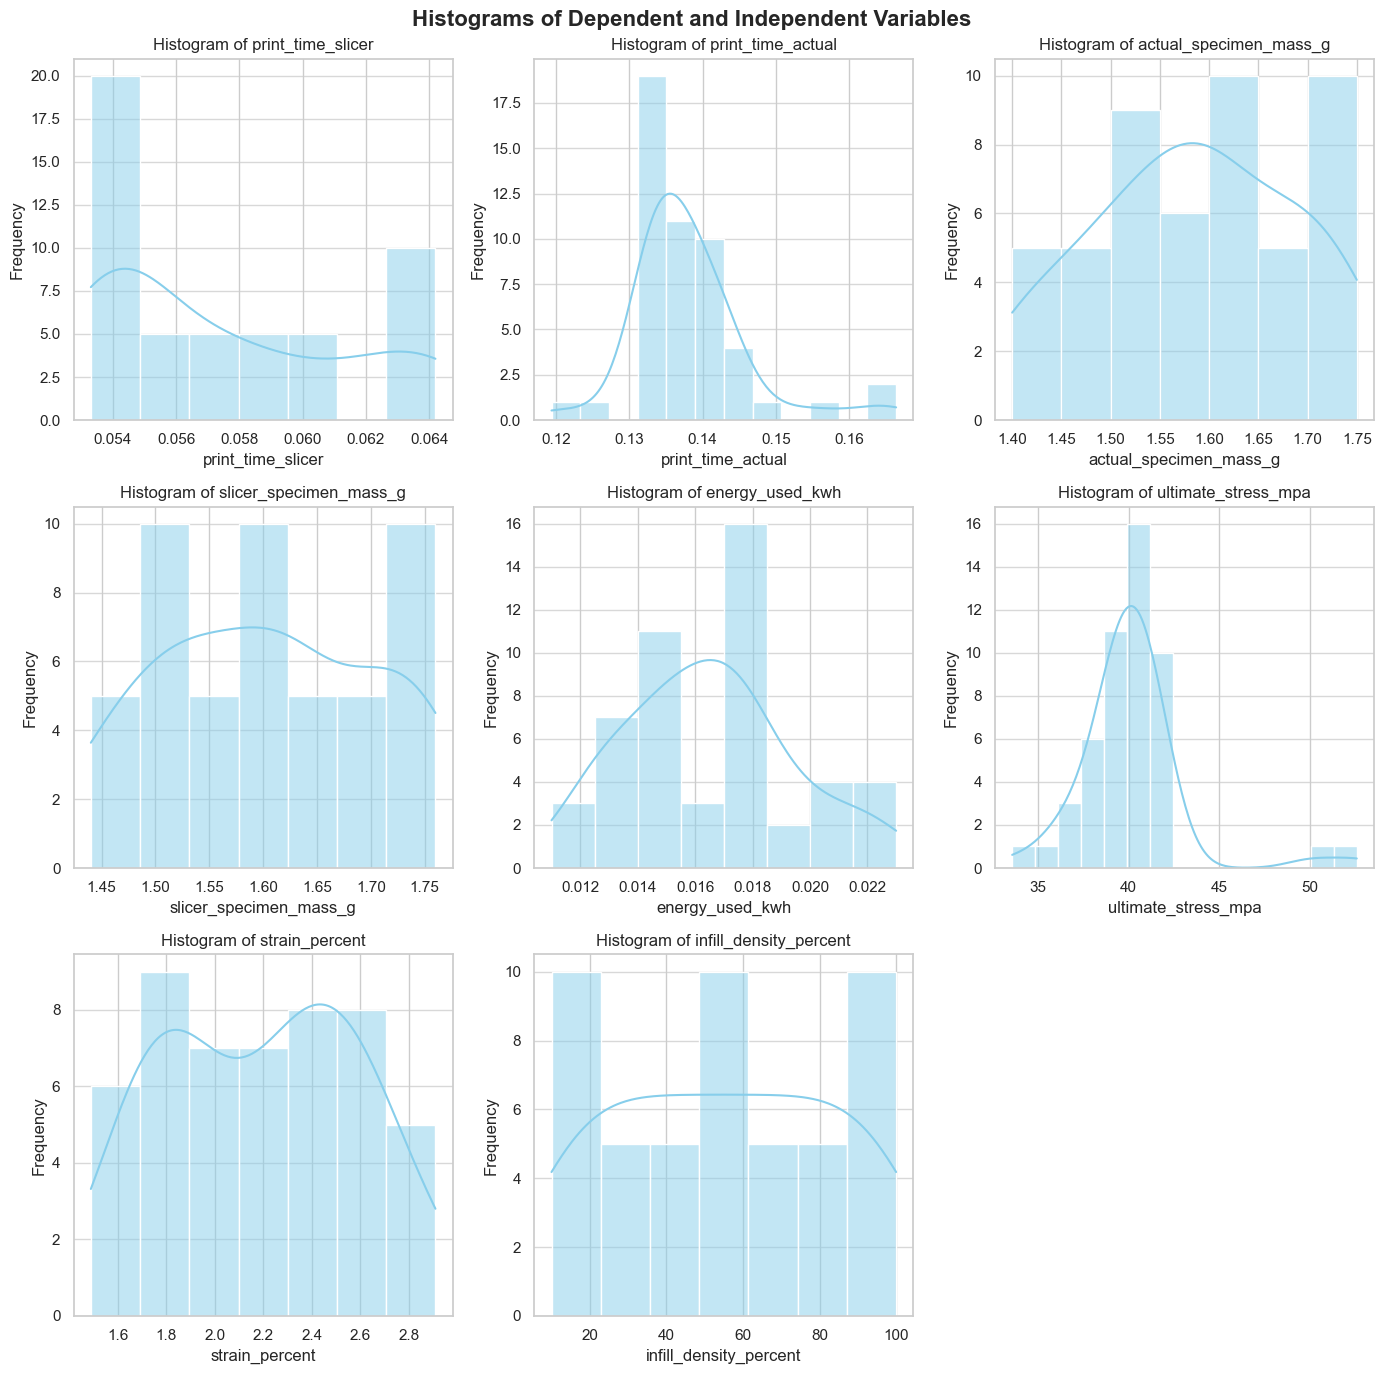

In [33]:
# Create a histogram of the dataset
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for idx, var in enumerate(all_vars):
    ax = axes[idx]
    sns.histplot(df[var], kde=True, color='skyblue', ax=ax)
    ax.set_title(f'Histogram of {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.75)

# Hide unused subplots
for idx in range(len(all_vars), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Histograms of Dependent and Independent Variables', fontsize=16, fontweight='bold')  
plt.tight_layout()
plt.show()

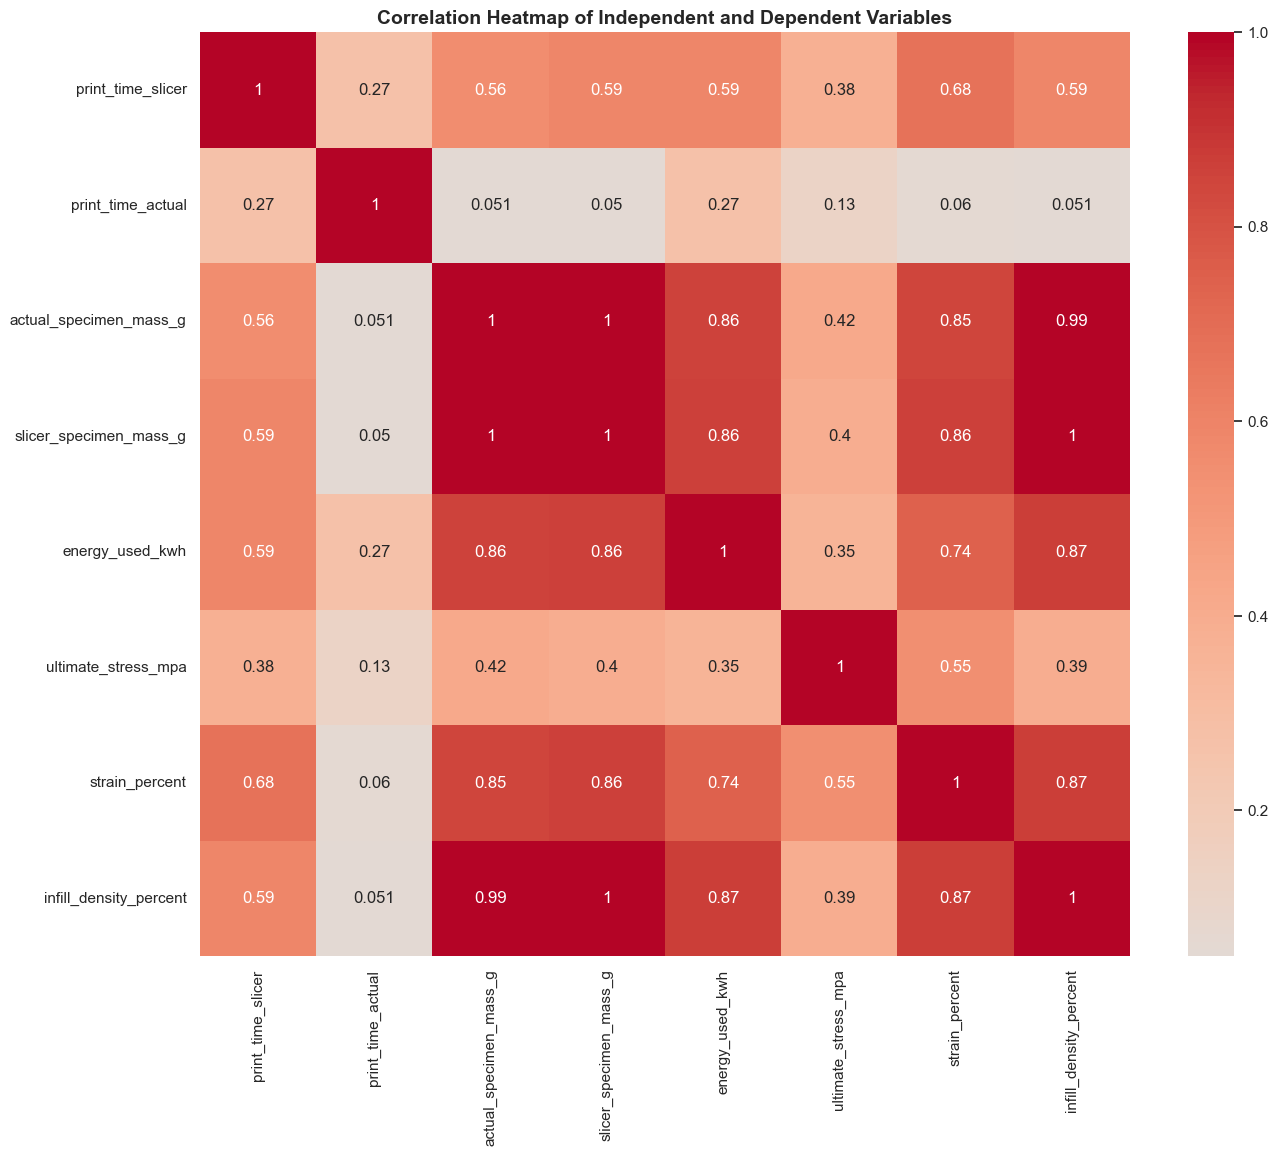

In [34]:
# Correlation Heatmap between independent and dependent variables
plt.figure(figsize=(15, 12))
corr_matrix = df[all_vars].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Independent and Dependent Variables', fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.show()

### Checking Missing Values

CHECKING MISSING VALUES
          Column  Missing_Count  Missing_Percentage
remarks  remarks             48                96.0


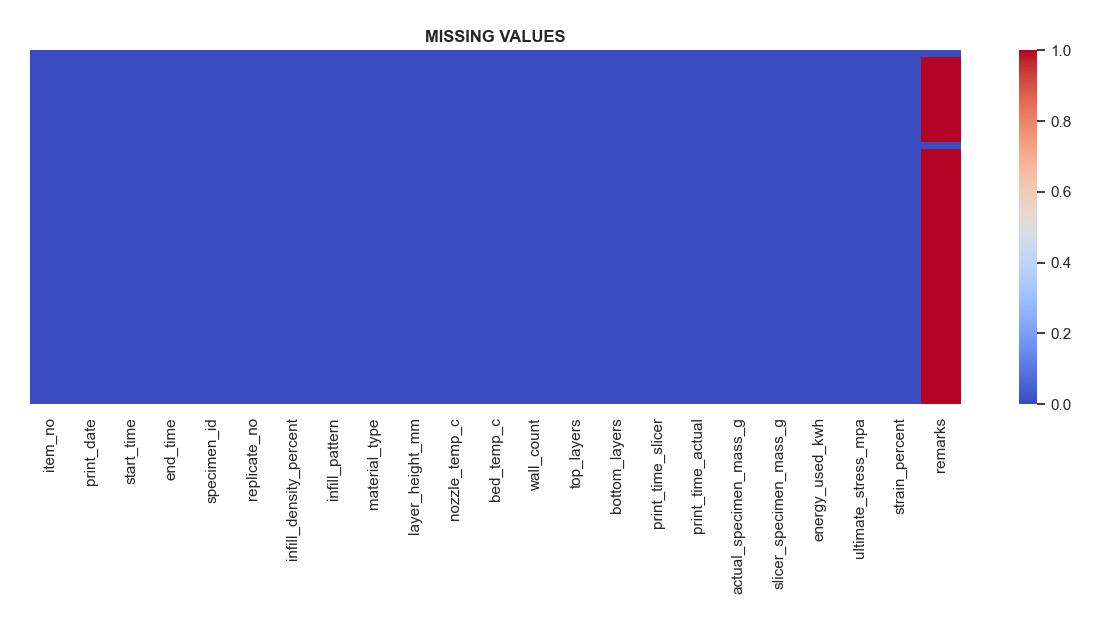

In [ ]:
#Checking for Missing Values
print("="*100)
print(str.upper("Checking Missing Values"))
print("=" * 100)

missing = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing) == 0:
    print("No missing values found!")
else:
    print(missing)

# Visualize missing values
if df.isnull().sum().sum() > 0:
    sns.heatmap(df.isnull(), cbar=True, cmap='coolwarm', yticklabels=False)
    plt.title(str.upper('Missing Values'))
    plt.tight_layout()
    plt.show()

### Checking for Duplicates

In [ ]:
# Check for duplicates
print("=" * 100)
print(str.upper("Duplciate Values"))
print("=" * 100)
duplicates = df.duplicated().sum()
print(f"Total Duplicates: {duplicates}")
print(f"Percentage: {(duplicates/len(df)*100).round(2)}%")

if duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

DUPLCIATE VALUES
Total Duplicates: 0
Percentage: 0.0%


### Checking for Outliers

In [ ]:
# Check for outliers using IQR method
print("=" * 100)
print("Potential Outliers (Numeric Columns)")
print("=" * 100)
numeric_cols = df.select_dtypes(include=[np.number]).columns

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary.append({
        'Column': col,
        'Outliers': outliers,
        'Percentage': (outliers/len(df)*100).round(2),
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

Potential Outliers (Numeric Columns)
                    Column  Outliers  Percentage  Lower_Bound  Upper_Bound
0                  item_no         0         0.0   -23.500000    74.500000
1             replicate_no         0         0.0    -1.000000     7.000000
2   infill_density_percent         0         0.0   -45.000000   155.000000
3          layer_height_mm         0         0.0     0.200000     0.200000
4            nozzle_temp_c         0         0.0   220.000000   220.000000
5               bed_temp_c         0         0.0    50.000000    50.000000
6               wall_count         0         0.0     2.000000     2.000000
7               top_layers         0         0.0     5.000000     5.000000
8            bottom_layers         0         0.0     5.000000     5.000000
9        print_time_slicer         0         0.0     0.044300     0.070700
10       print_time_actual         4         8.0     0.122462     0.152163
11  actual_specimen_mass_g         0         0.0     1.270000  

## 4. Descriptive Statistics

In [ ]:
# Summary statistics for numeric columns
print("="*100)
print("Descriptive Statistics (Numeric)")
print("="*100)
print(df.describe().T)  # .T transposes for better readability

Descriptive Statistics (Numeric)
                        count        mean           std        min  \
item_no                  50.0   25.500000  1.457738e+01    1.00000   
replicate_no             50.0    3.000000  1.428571e+00    1.00000   
infill_density_percent   50.0   55.000000  2.901442e+01   10.00000   
layer_height_mm          50.0    0.200000  5.607473e-17    0.20000   
nozzle_temp_c            50.0  220.000000  0.000000e+00  220.00000   
bed_temp_c               50.0   50.000000  0.000000e+00   50.00000   
wall_count               50.0    2.000000  0.000000e+00    2.00000   
top_layers               50.0    5.000000  0.000000e+00    5.00000   
bottom_layers            50.0    5.000000  0.000000e+00    5.00000   
print_time_slicer        50.0    0.057430  3.908403e-03    0.05330   
print_time_actual        50.0    0.138206  7.960423e-03    0.11940   
actual_specimen_mass_g   50.0    1.584200  1.039445e-01    1.40000   
slicer_specimen_mass_g   50.0    1.604000  1.015392e-01  

In [ ]:
# Summary statistics for categorical columns
print("="*100)
print("Categorical Columns Summary")
print("="*100)
categorical_cols = df.select_dtypes(include=['object', 'str']).columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

Categorical Columns Summary

print_date:
print_date
4/15/2026    20
4/16/2026    20
4/14/2026    10
Name: count, dtype: int64
Unique values: 3

start_time:
start_time
15:04:53    1
15:15:57    1
15:25:15    1
15:34:26    1
15:43:59    1
16:47:31    1
16:56:54    1
17:06:30    1
17:16:11    1
17:27:02    1
08:24:21    1
08:37:41    1
08:50:37    1
09:24:03    1
09:37:46    1
10:49:18    1
12:09:16    1
12:20:39    1
12:32:18    1
13:18:31    1
14:51:15    1
15:03:22    1
15:14:37    1
15:26:23    1
15:38:50    1
16:53:58    1
17:07:07    1
17:18:24    1
17:30:01    1
17:41:26    1
08:16:39    1
08:30:48    1
09:06:56    1
09:18:46    1
09:31:14    1
09:43:06    1
09:55:02    1
10:09:45    1
10:29:23    1
10:44:32    1
12:10:29    1
12:25:10    1
12:51:31    1
13:04:57    1
13:17:35    1
13:30:55    1
15:19:53    1
15:32:28    1
15:45:29    1
17:15:14    1
Name: count, dtype: int64
Unique values: 50

end_time:
end_time
15:14:15    1
15:23:30    1
15:33:12    1
15:42:32    1
15:51:56    1

## 4. Exploratory Data Analysis

### Inspecting Outliers Through Boxplot

Advanced: Boxplots with Statistical Information (Seaborn)


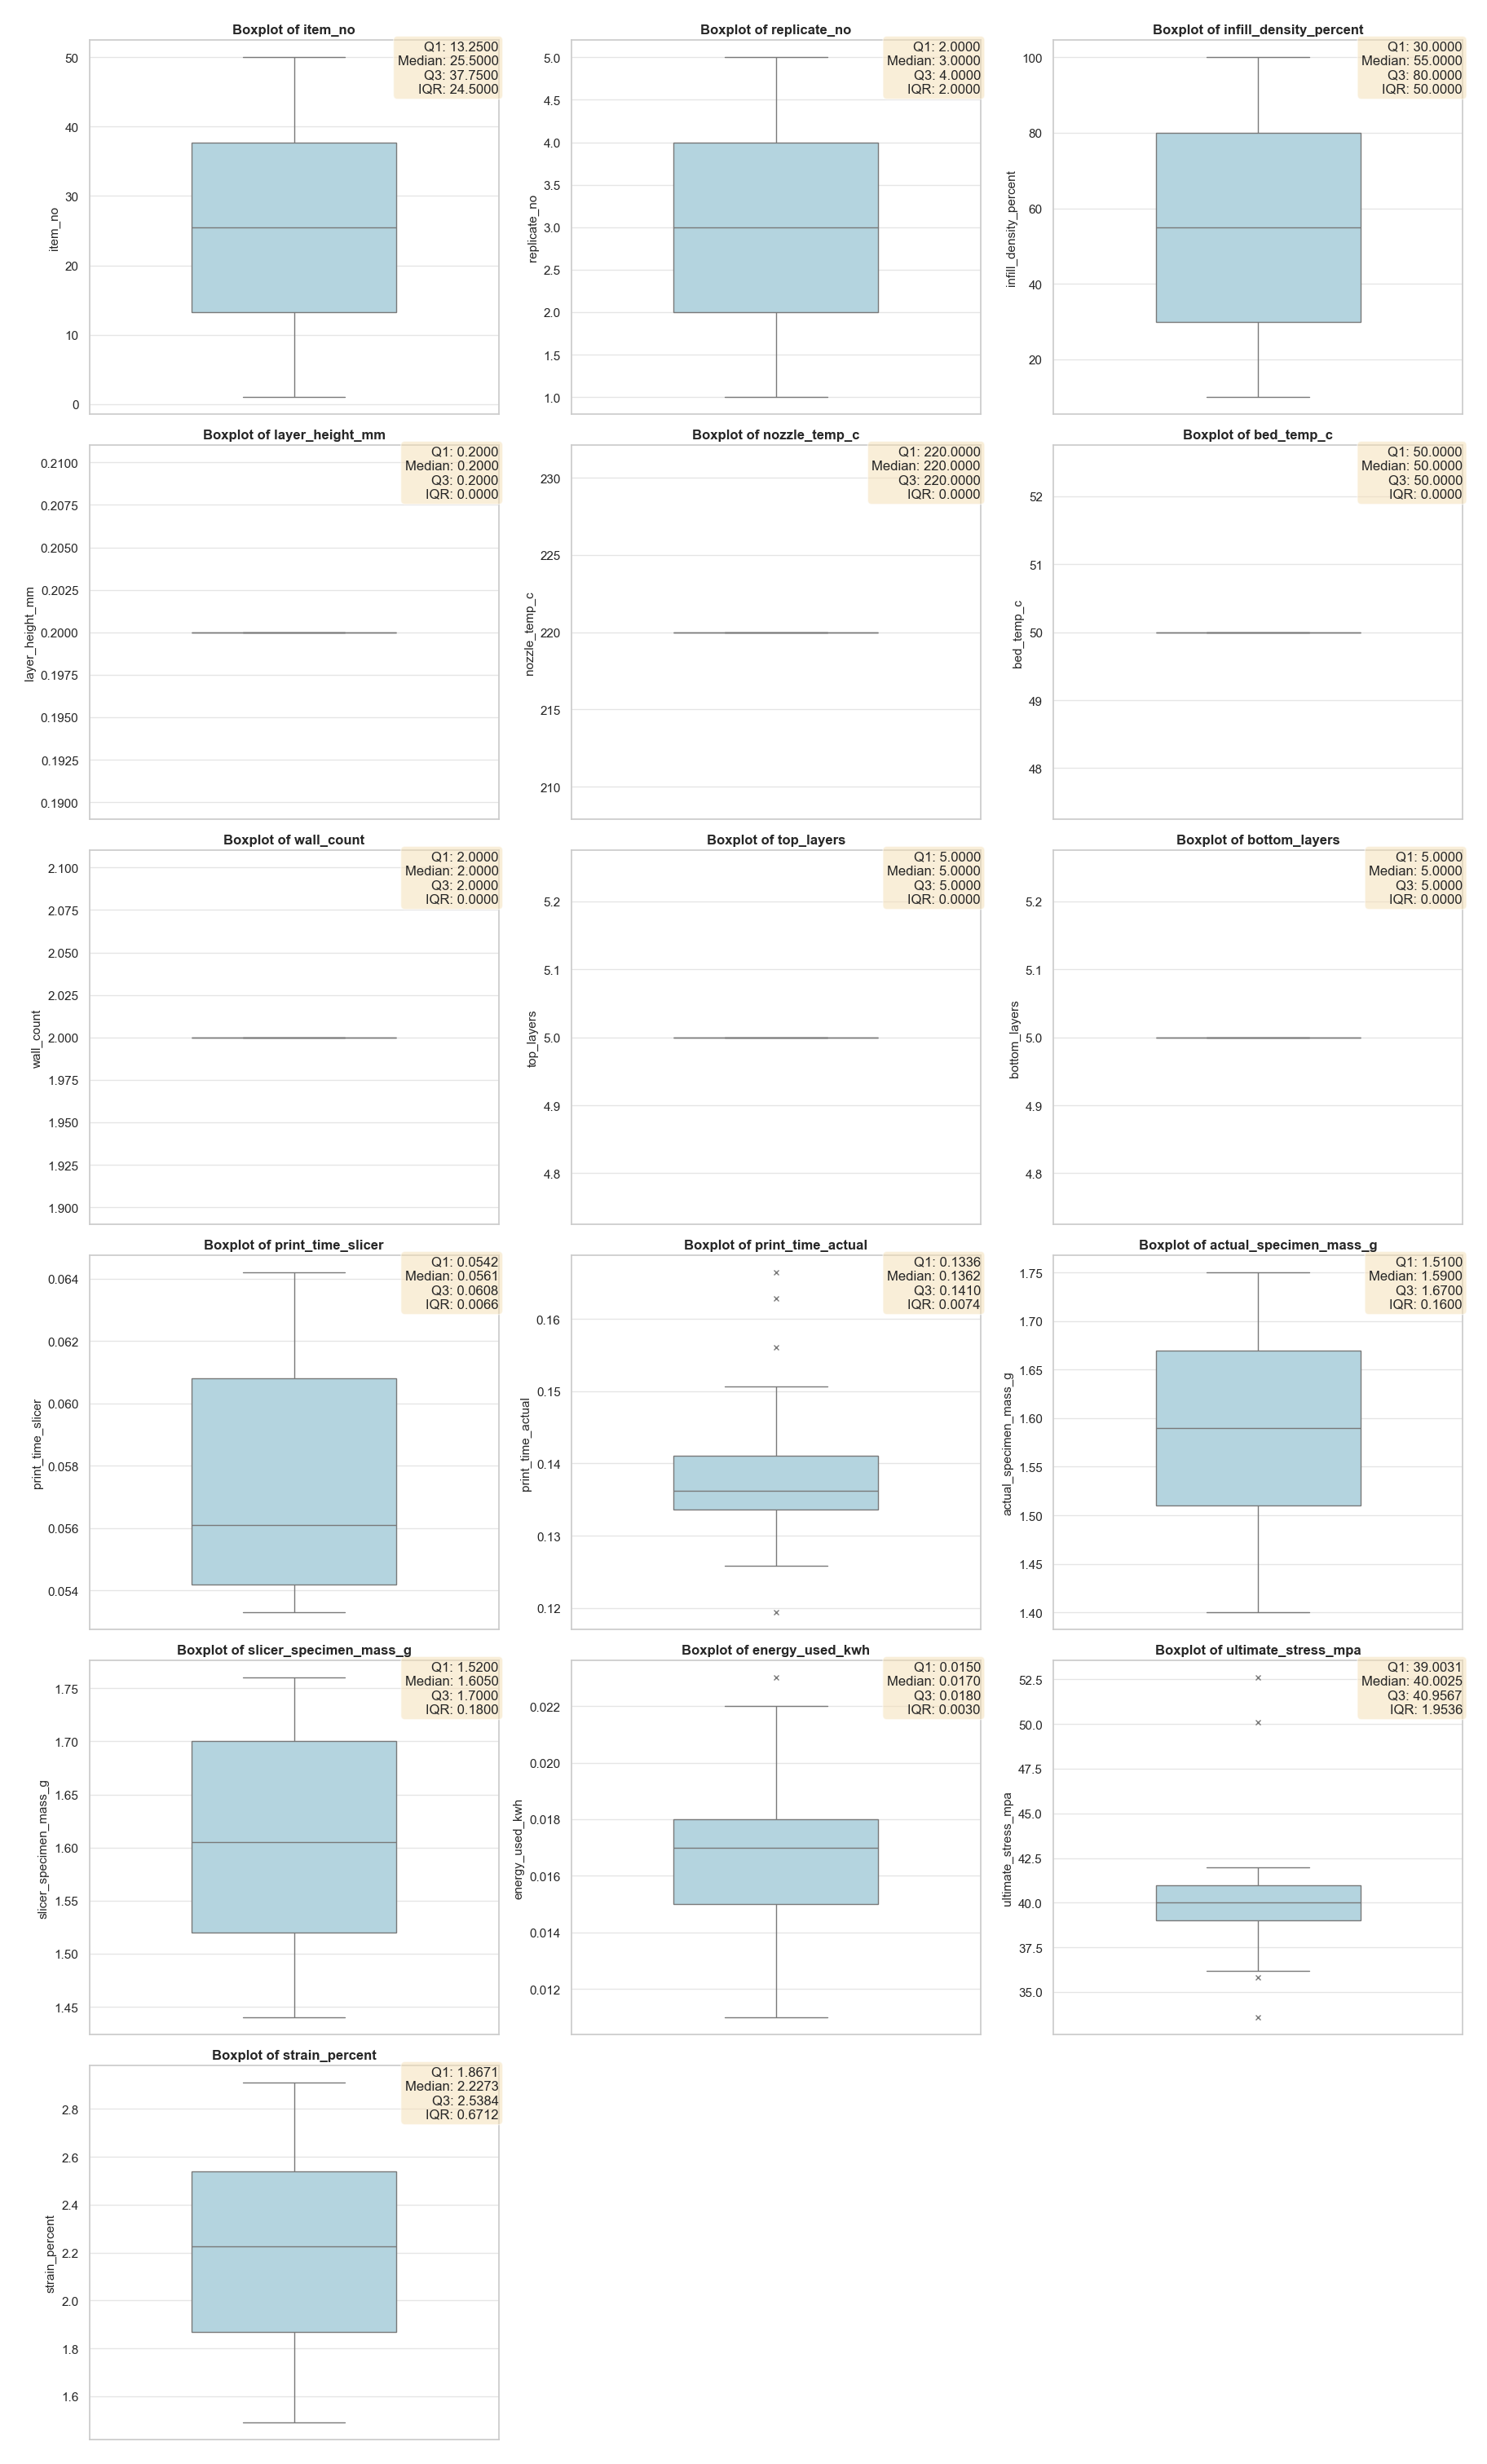

In [ ]:
print("="*100)
print("Advanced: Boxplots with Statistical Information (Seaborn)")
print("="*100)

sns.set_style("whitegrid")

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    

    sns.boxplot(
        y=df[col],
        ax=ax,
        color='lightblue',
        width=0.5,
        fliersize=3,
        flierprops={'marker': 'x', 'markersize': 5} 
        
    )
    
    ax.set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col, fontsize=11)
    
    # Compute statistics
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    stats_text = (
        f'Q1: {q1:.4f}\n'
        f'Median: {q2:.4f}\n'
        f'Q3: {q3:.4f}\n'
        f'IQR: {iqr:.4f}'
    )
    
    # Stable placement (top-right corner)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    ax.text(
        xlim[1], ylim[1],
        stats_text,
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        verticalalignment='top',
        horizontalalignment='right'
    )

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

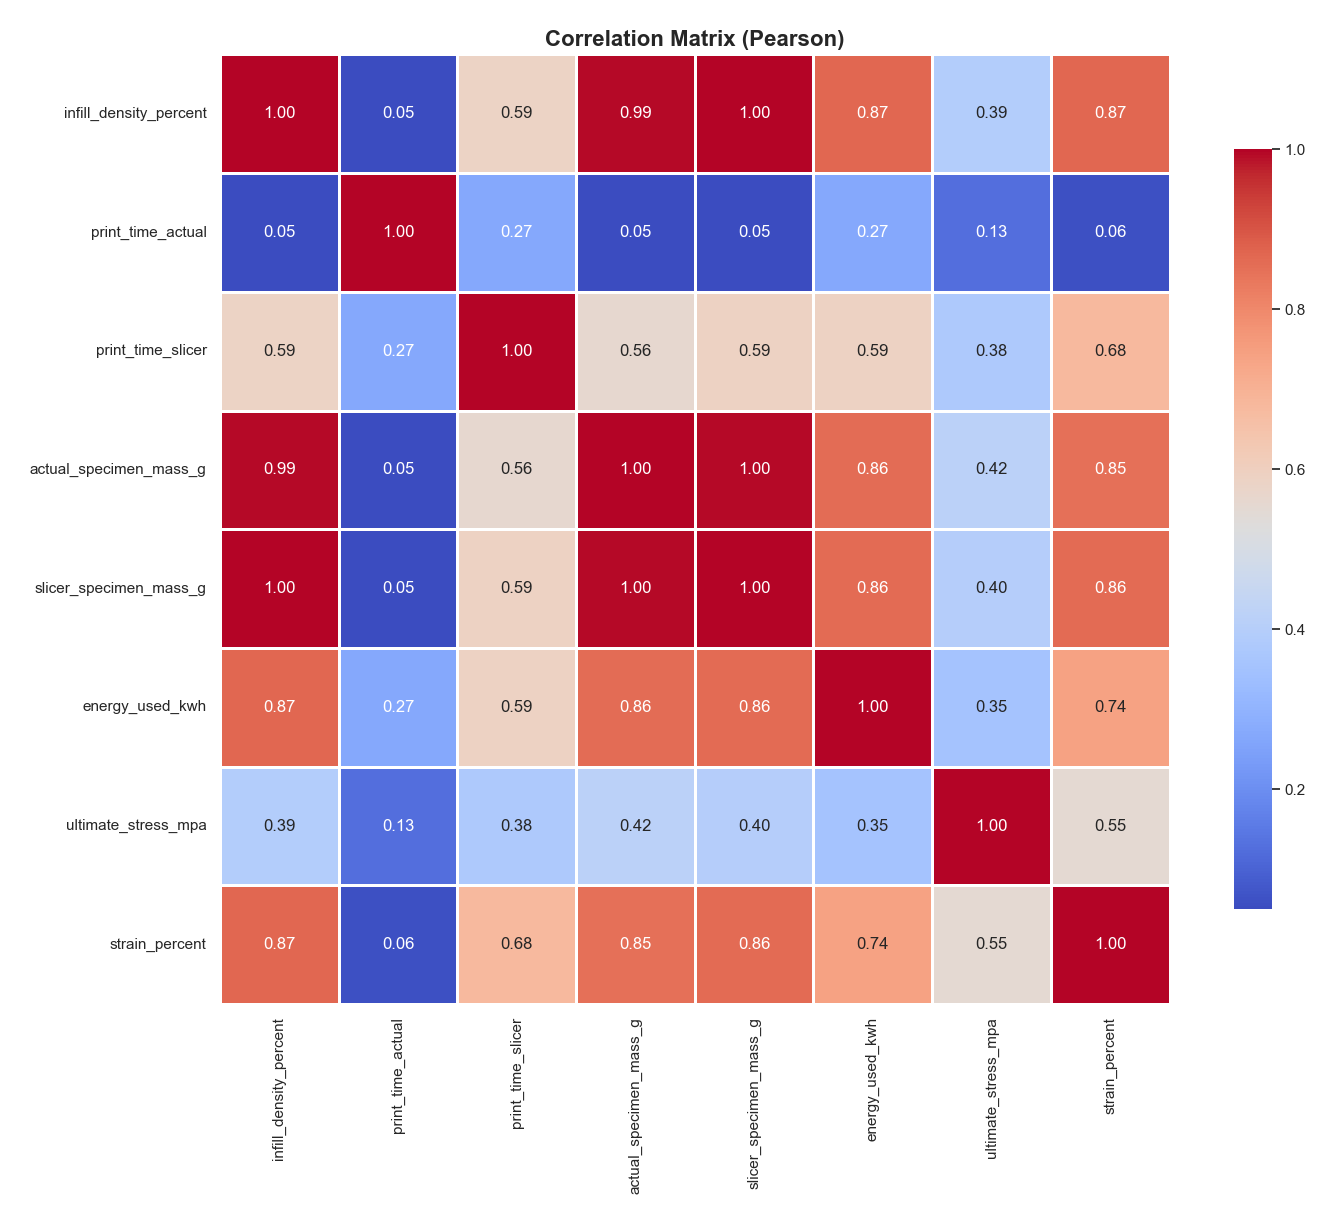

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    'infill_density_percent',
    'print_time_actual',
    'print_time_slicer',
    'actual_specimen_mass_g',
    'slicer_specimen_mass_g', 
    'energy_used_kwh',
    'ultimate_stress_mpa',
    'strain_percent'
]

plt.figure(figsize=(15, 12))

corr_matrix = df[corr_cols].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=1, square=True, cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix (Pearson)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df.count(numeric_only=True)

item_no                   50
replicate_no              50
infill_density_percent    50
layer_height_mm           50
nozzle_temp_c             50
bed_temp_c                50
wall_count                50
top_layers                50
bottom_layers             50
print_time_slicer         50
print_time_actual         50
actual_specimen_mass_g    50
slicer_specimen_mass_g    50
energy_used_kwh           50
ultimate_stress_mpa       50
strain_percent            50
dtype: int64

### Line Graph of Numerical Columns

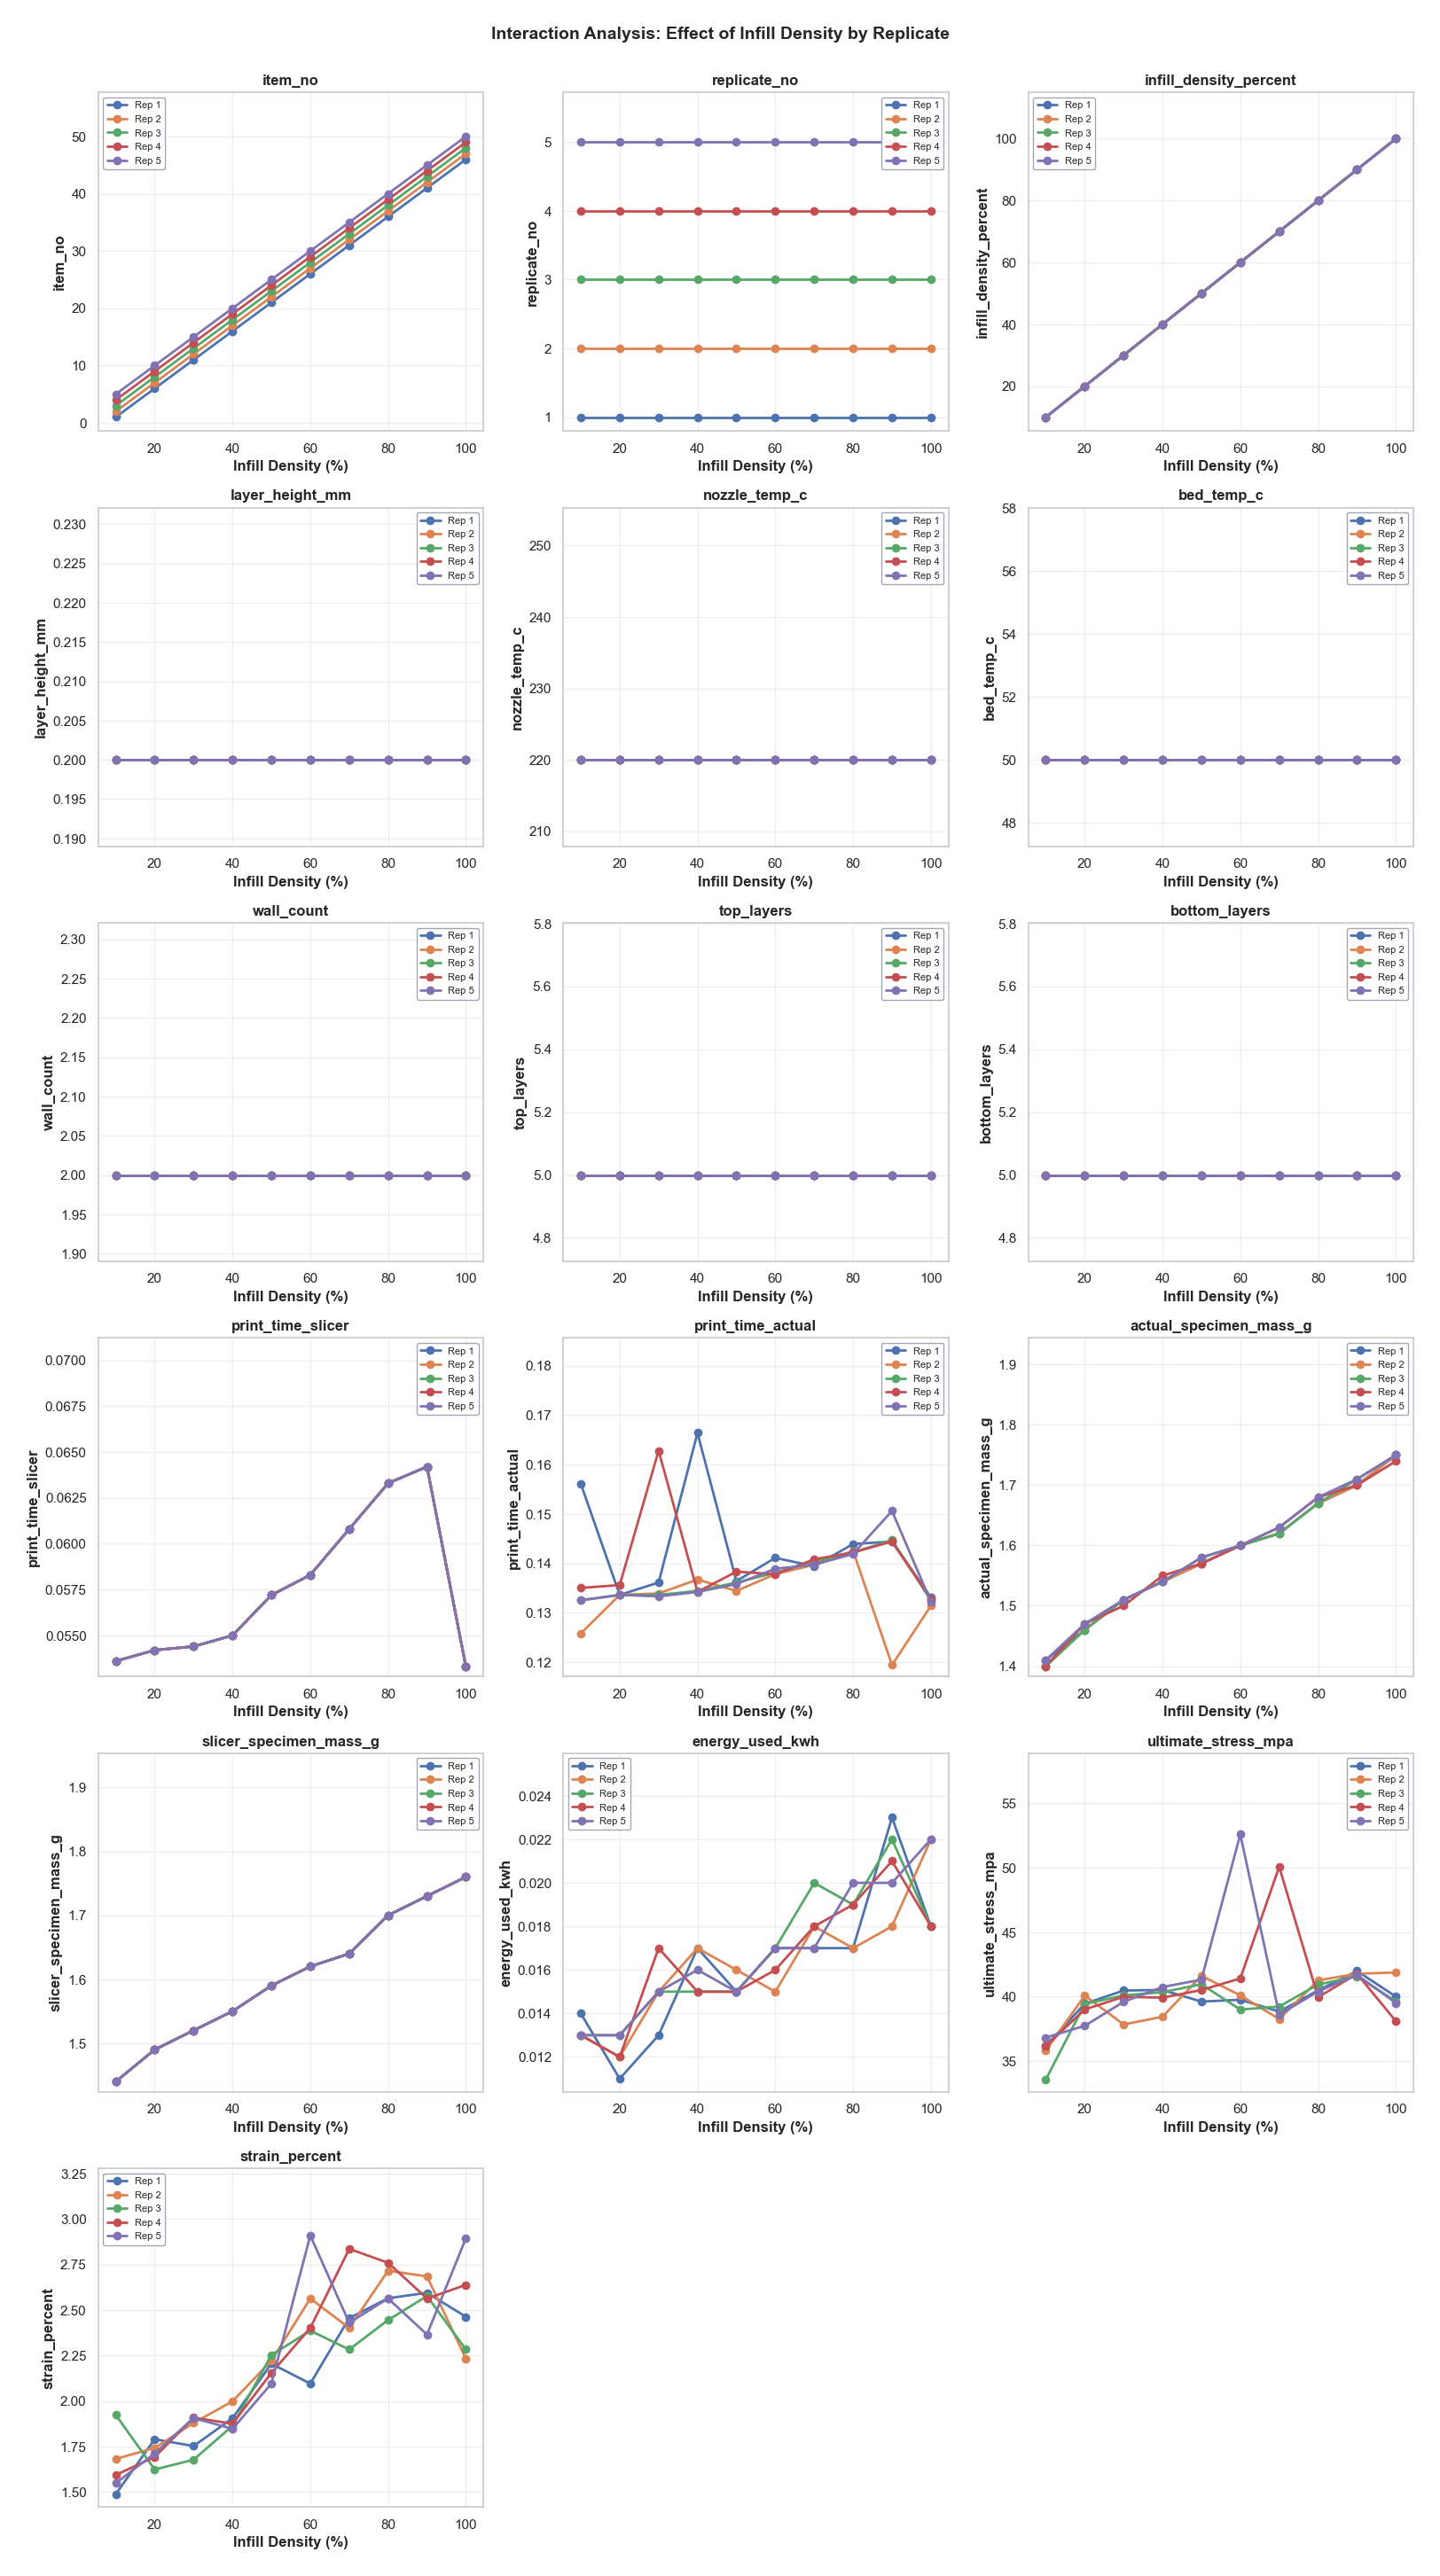

In [ ]:
fig, axes = plt.subplots(16, 3, figsize=(16, 75))

fig.suptitle('Interaction Analysis: Effect of Infill Density by Replicate', 
             fontsize=14, fontweight='bold', y=1)

axes = axes.flatten()

for idx, col in enumerate(numeric_cols):

    for rep in sorted(df['replicate_no'].unique()):
        
        grouped = (
            df[df['replicate_no'] == rep]
            .groupby('infill_density_percent')[col]
            .mean()
            .sort_index()
        )

        axes[idx].plot(
            grouped.index,
            grouped.values,
            marker='o',
            linewidth=2,
            label=f'Rep {int(rep)}'
        )

    axes[idx].set_xlabel('Infill Density (%)', fontweight='bold')
    axes[idx].set_ylabel(col, fontweight='bold')
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

    # Cleaner legend (only once per subplot)
    axes[idx].legend(fontsize=8)

    # headroom
    y_min, y_max = axes[idx].get_ylim()
    axes[idx].set_ylim(y_min, y_max * 1.1)

# remove unused axes
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

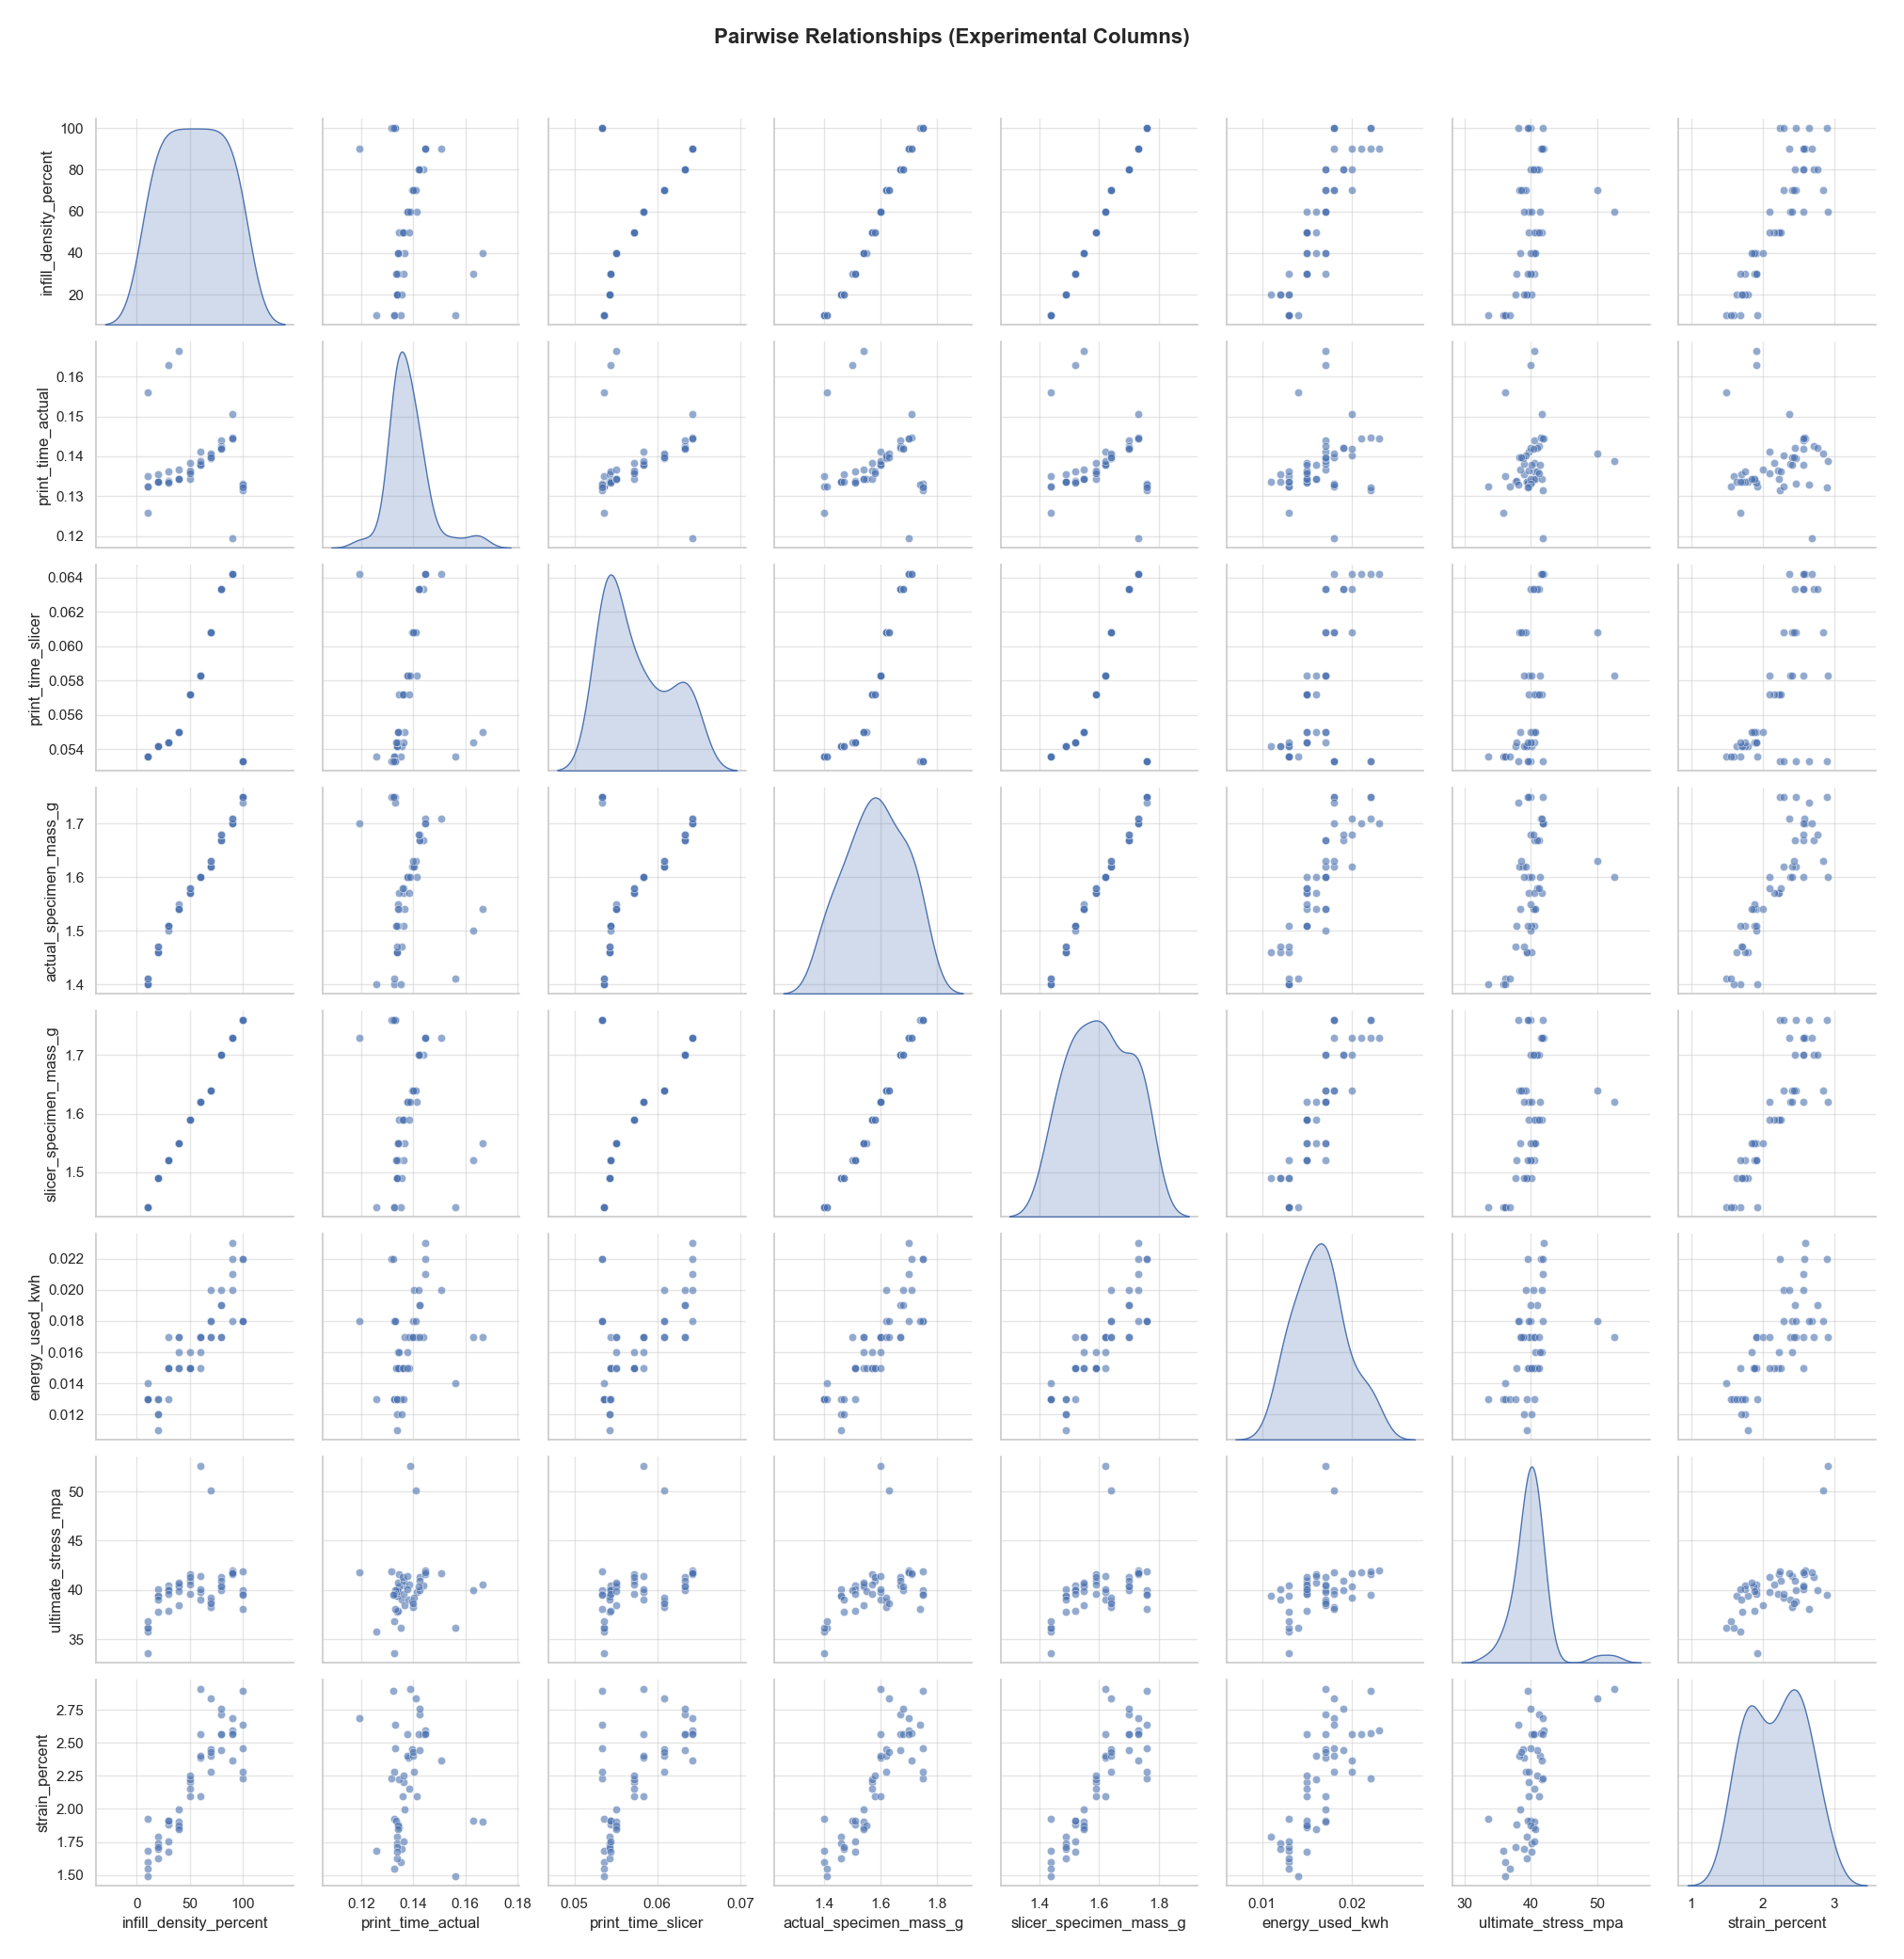

In [ ]:
experimental_cols = ['infill_density_percent', 'print_time_actual', 'print_time_slicer', 'actual_specimen_mass_g', 'slicer_specimen_mass_g', 'energy_used_kwh', 'ultimate_stress_mpa', 'strain_percent']

sns.pairplot(df[experimental_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairwise Relationships (Experimental Columns)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout() 
plt.show()